# Detect Pigeons by Fine Tuning MobilenetV2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marbetschar/pigeon-detector/blob/master/mobilenet_v2.ipynb)

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import models, transforms

import matplotlib.pyplot as plt
import numpy as np

from dataset.pytorch import PigeonBBoxDataset

IMAGENET_MEAN = [0.485, 0.456, 0.406] # ImageNet mean
IMAGENET_STD  = [0.229, 0.224, 0.225] # ImageNet std

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")

## Transforms & Dataset

In [3]:
# ImageNet-style transforms (good for MobileNetV2)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # MobileNetV2 default input size
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

json_path = "dataset/labels.json"
images_root = "dataset/images"

full_dataset = PigeonBBoxDataset(
    json_path=json_path,
    images_root=images_root,
    transform=train_transform,
    normalize_bboxes=True,
)

In [4]:
positive_samples = 0
negative_samples = 0

for sample in full_dataset.samples:
    confidence = sample["bboxes"][0][0]
    if confidence:
        positive_samples += 1
    else:
        negative_samples += 1

len(full_dataset), positive_samples, negative_samples

(3000, 1959, 1041)

## Train/Val Split & DataLoaders

In [5]:
val_ratio = 0.2
n_total = len(full_dataset)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [n_train, n_val], generator=generator)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

## Model

In [6]:
# Load pretrained MobileNetV2
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Replace the classifier head to output 4 bbox values [x, y, w, h]
in_features = mobilenet.classifier[-1].in_features
mobilenet.classifier[-1] = nn.Sequential(
    nn.Linear(in_features, 5),
    nn.Sigmoid(),  # maps outputs to (0,1)
)

mobilenet = mobilenet.to(device)

# Freeze all but the classifier:
for param in mobilenet.features.parameters():
    param.requires_grad = False

## Training & Validation

In [7]:
import matplotlib.pyplot as plt

def plot_losses(epochs, train_losses, val_losses):
    plt.figure()
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training / Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


In [9]:
criterion = nn.MSELoss() # or nn.SmoothL1Loss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet.parameters()),
    lr=1e-4,
)

num_epochs = 1  # adjust as needed
best_val_loss = float("inf")
save_path = "models/mobilenet_v2.pth"

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    mobilenet.train()
    running_loss = 0.0

    mobilenet.train()
    running_train_loss = 0.0

    for images, bboxes in train_loader:
        images = images.to(device)
        bboxes = bboxes.to(device)  # normalized [B,4] in [0,1]

        optimizer.zero_grad()

        outputs = mobilenet(images)  # normalized preds [B,4] in (0,1)
        loss = criterion(outputs, bboxes)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    #################
    # Val phase     #
    #################
    mobilenet.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, bboxes in val_loader:
            images = images.to(device)
            bboxes = bboxes.to(device)  # normalized GT

            outputs = mobilenet(images)  # normalized predictions
            loss = criterion(outputs, bboxes)

            running_val_loss += loss.item() * images.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f}")

    # Save best model based on val loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(mobilenet.state_dict(), save_path)
        print(f"  ✔ New best model saved with val loss {best_val_loss:.4f} to '{save_path}'")

Epoch [1/1] - Train Loss: 0.0706 - Val Loss: 0.0648
  ✔ New best model saved with val loss 0.0648 to 'models/mobilenet_v2.pth'


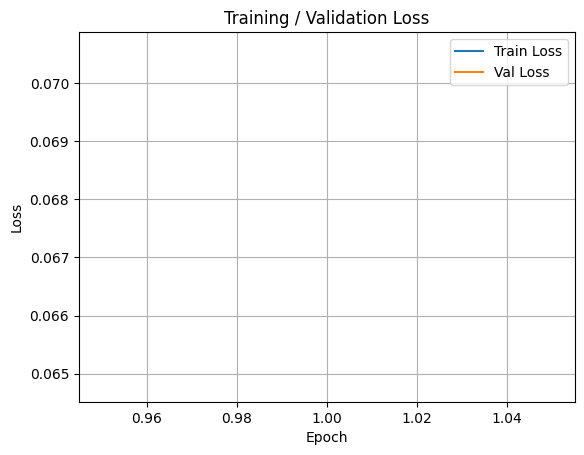

In [10]:
plot_losses(range(1, num_epochs + 1), train_losses, val_losses)
# Best Validation Loss of Previous Run: 0.0268

## Pigeon Detection Visualization

In [11]:
def denormalize_image(tensor):
    """
    tensor: (3, H, W), normalized
    returns: (H, W, 3) numpy array in [0, 1]
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = tensor * std + mean
    img = img.clamp(0.0, 1.0)
    img = img.permute(1, 2, 0)  # (H, W, C)
    return img.cpu().numpy()

def visualize_prediction(model, dataset, idx, device, ax):
    """
    model: trained MobileNetV2 bbox regressor
    dataset: e.g. val_dataset
    idx: index in the dataset to visualize
    device: torch.device
    """
    model.eval()

    # Get sample
    img_tensor, gt_bbox = dataset[idx]  # img: (3,H,W) tensor, gt_bbox: (4,) tensor
    gt_bbox = gt_bbox.numpy()

    # Model prediction
    with torch.no_grad():
        input_tensor = img_tensor.unsqueeze(0).to(device)  # add batch dim
        pred_bbox = model(input_tensor)[0].cpu().numpy()   # (4,)

    # Denormalize image for plotting
    img_np = denormalize_image(img_tensor)
    H, W = img_np.shape[:2]

    # Un-normalize: [0,1] -> pixel coords
    gprob, gx, gy, gw, gh = gt_bbox
    gx, gy, gw, gh = gx * W, gy * H, gw * W, gh * H

    pprob, px, py, pw, ph = pred_bbox
    px, py, pw, ph = px * W, py * H, pw * W, ph * H

    ax.imshow(img_np)

    # Ground truth bbox
    rect_gt = plt.Rectangle(
        (gx, gy), gw, gh,
        linewidth=2,
        edgecolor='g',
        facecolor='none',
        label=f'GT: {gprob:.2f}'
    )
    ax.add_patch(rect_gt)

    # Predicted bbox
    rect_pred = plt.Rectangle(
        (px, py), pw, ph,
        linewidth=2,
        edgecolor='r',
        facecolor='none',
        label=f'Pred: {pprob:.2f}'
    )
    ax.add_patch(rect_pred)

    ax.legend()
    ax.set_axis_off()

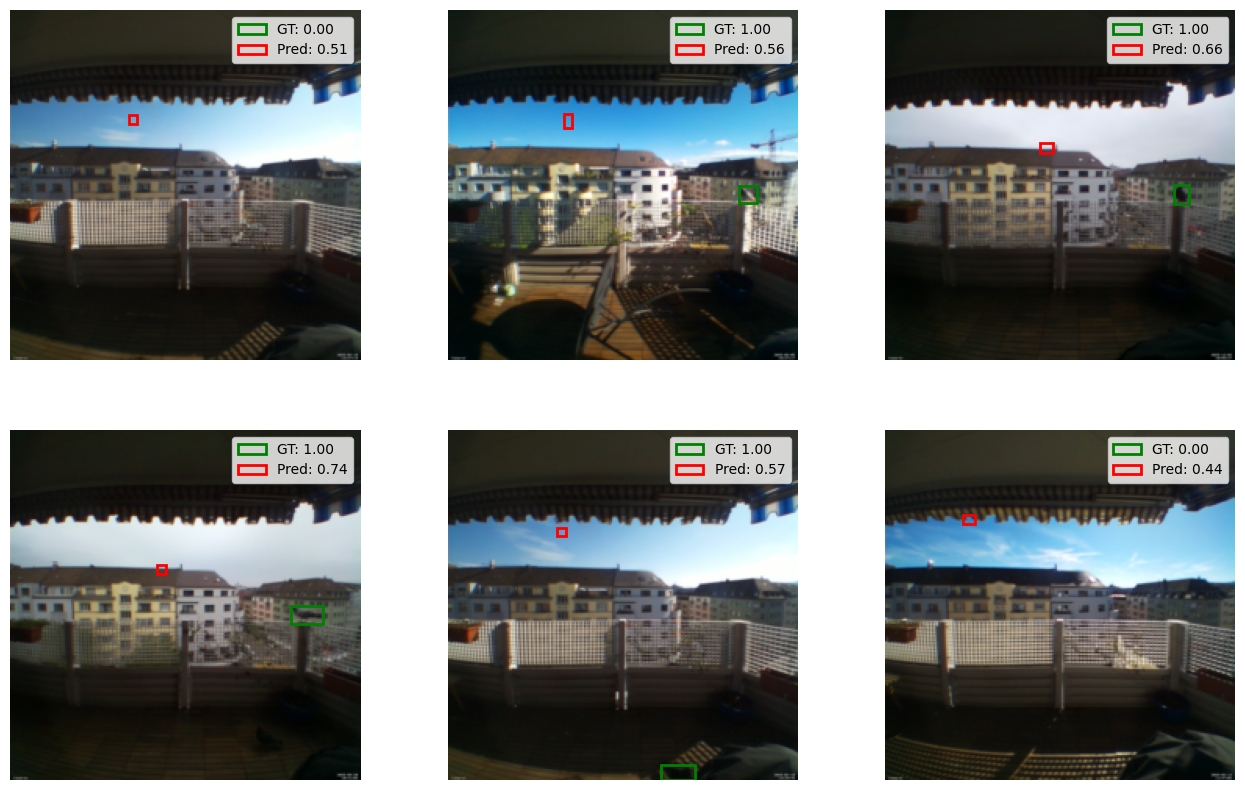

In [12]:
plt.figure(figsize=(16, 10))
for i in range(6):
    ax = plt.subplot(2, 3, i+1)
    idx = np.random.randint(len(train_dataset))
    visualize_prediction(mobilenet, train_dataset, idx=idx, device=device, ax=ax)

## Inference with Existing Model

In [20]:
from PIL import Image

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def load_mobilenet_v2_model(weights_path: str, device: torch.device):
    """
    Load MobileNetV2 bbox regression model from a state_dict (.pth file).
    Assumes:
      - classifier[-1] is Sequential(Linear(4), Sigmoid) for normalized outputs.
    """
    # Base architecture
    model = models.mobilenet_v2(weights=None)  # weights=None because we'll load our own

    # Must match what you used during training:
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Sequential(
        nn.Linear(in_features, 5),
        nn.Sigmoid(),
    )

    # Load weights
    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()
    return model

def predict(model, image_path: str, device: torch.device):
    """
    Run inference on a single image and return bounding box in *original* pixel coords
    """
    # # Load image
    # img = Image.open(image_path).convert("RGB")
    # orig_w, orig_h = img.size  # original size in pixels
    #
    # # Apply same preprocessing as during training
    # input_tensor = inference_transform(img).unsqueeze(0).to(device)  # [1, 3, 224, 224]
    #

    import cv2

    mean = np.array([0.485, 0.456, 0.406]).reshape(1, 1, 3)
    std = np.array([0.229, 0.224, 0.225]).reshape(1, 1, 3)

    image = cv2.imread(image_path)
    orig_h, orig_w = image.shape[:2]

    image_resized = cv2.resize(image, [224, 224])
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
    image_norm = ((image_rgb.astype(np.float32) / 255.0) - mean) / std

    input_tensor = torch.Tensor(image_norm.reshape((3, 224, 224))).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(input_tensor)[0].cpu()  # [4], normalized (0..1)

    # Convert normalized [0,1] -> pixel coords of original image
    confidence, x_norm, y_norm, w_norm, h_norm = pred.tolist()
    x = x_norm * orig_w
    y = y_norm * orig_h
    w = w_norm * orig_w
    h = h_norm * orig_h

    return confidence, x, y, w, h

In [21]:
model = load_mobilenet_v2_model("models/mobilenet_v2.pth", device=device)
prediction = predict(model, "dataset/images/2025-09-01_07-51-45.jpg", device=device)
prediction

(0.3601146936416626,
 283.0247497558594,
 234.4209747314453,
 57.71332931518555,
 80.99716186523438)

# Hailo Hardware

## Convert to ONNX

In [19]:
inputs = (torch.randn(1, 3, 224, 224).to(device),)
onnx_model = torch.onnx.export(mobilenet, inputs, dynamo=True)
onnx_model.save(save_path + ".onnx")

[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV2([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 104 of general pattern rewrite rules.


Some nodes in our ONNX graph have no kernel_shape attribute, but Hailo’s code assumes it always exists. So we need to patch the onnx model to add the missing kernel_shape attributes:

In [31]:
import onnx
from onnx import helper

model = onnx.load(save_path + ".onnx")
graph = model.graph

initializer_map = {init.name: init for init in graph.initializer}

for node in graph.node:
    if node.op_type != "Conv":
        continue

    # Skip if kernel_shape already present
    ks = [a for a in node.attribute if a.name == "kernel_shape"]
    if ks:
        continue

    # Assume second input is the weight tensor
    if len(node.input) < 2:
        print("WARNING: Conv node with no weight input:", node.name)
        continue

    W_name = node.input[1]
    W_init = initializer_map.get(W_name)
    if W_init is None:
        print("WARNING: no initializer found for weight", W_name, "in node", node.name)
        continue

    dims = list(W_init.dims)
    if len(dims) < 4:
        print("WARNING: unexpected weight shape", dims, "for node", node.name)
        continue

    # Conv weights: [out_channels, in_channels/group, kH, kW]
    kH, kW = dims[-2], dims[-1]
    print(f"Adding kernel_shape={kH, kW} to node {node.name}")

    node.attribute.append(helper.make_attribute("kernel_shape", [kH, kW]))

onnx.save(model, save_path + ".onnx")

### Calibration Set

In [5]:
import os
from PIL import Image

model_input_width = 224
model_output_height = 224
calibset_images_path = "dataset/images"

# Apply preprocessing to all images in the calibration folder
images_list = [img for img in os.listdir(calibset_images_path) if img.endswith(".jpg")]
calibset = np.zeros((len(images_list), model_output_height, model_input_width, 3))

for idx, img_name in enumerate(sorted(images_list)):
    img = Image.open(os.path.join(calibset_images_path, img_name))
    img_preproc = train_transform(img).reshape(1, model_output_height, model_input_width, 3)
    calibset[idx] = img_preproc.numpy()

np.save("dataset/calibset.npy", calibset)  # Save for reuse

## Install Hailo Dataflow Compiler

Run the following on Ubuntu 22.04 x64:

In [ ]:
apt update
apt install python3 python3.10-venv python-is-python3 build-essential graphviz libgraphviz-dev
apt install ./hailort_4.23.0_amd64.deb # You'll need to download HailoRT *.deb from the Hailo Developer Zone

python3 -m venv .hailo_venv
source .hailo_venv/bin/activate

pip install hailo_dataflow_compiler-3.33.0-py3-none-linux_x86_64.whl # You'll need to download the compiler from the Hailo Developer Zone
pip install hailort-4.23.0-cp310-cp310-linux_x86_64.whl
hailo -h

## Parse ONNX to Hailo HAR

https://hailo.ai/developer-zone/documentation/dataflow-compiler-v3-31-0/?sp_referrer=tutorials_notebooks/notebooks/DFC_1_Parsing_Tutorial.html

Create and execute `parse.py`:

In [ ]:
#!/usr/bin/python3

from hailo_sdk_client import ClientRunner

runner = ClientRunner(hw_arch = "hailo8")
runner.translate_onnx_model("mobilenet_v2.pth.onnx")
runner.save_har("mobilenet_v2.har")

If, for some reason the python approach doesn't work: You can execute the following line instead:

In [ ]:
hailo parser onnx mobilenet_v2.pth.onnx --hw-arch=hailo8 --har-path=mobilenet_v2.har

## Optimize HAR

https://hailo.ai/developer-zone/documentation/dataflow-compiler-v3-31-0/?sp_referrer=tutorials_notebooks/notebooks/DFC_2_Model_Optimization_Tutorial.html

Create and execute `optimize.py`:

In [ ]:
#!/usr/bin/python3

from hailo_sdk_client import ClientRunner
import numpy as np

calibset = np.load("calibset.npy")

runner = ClientRunner(hw_arch = "hailo8", har="mobilenet_v2.har")
runner.optimize(calibset)
runner.save_har("mobilenet_v2_quantized.har")

If, for some reason the python approach doesn't work: You can execute the following line instead:

In [ ]:
hailo optimize mobilenet_v2.har --hw-arch=hailo8 --calib-set-path=calibset.npy --output-har-path=mobilenet_v2_quantized.har

## Compile HAR to HEF

https://hailo.ai/developer-zone/documentation/dataflow-compiler-v3-31-0/?sp_referrer=tutorials_notebooks/notebooks/DFC_3_Compilation_Tutorial.html

Create and execute `compile.py`:

In [ ]:
#!/usr/bin/python3

from hailo_sdk_client import ClientRunner

runner = ClientRunner(har="mobilenet_v2_quantized.har") # By default it uses the hw_arch that is saved on the HAR. It is not recommended to change the hw_arch after Optimization.
hef = runner.compile()

with open("mobilenet_v2.hef", "wb") as f:
    f.write(hef)

If, for some reason the python approach doesn't work: You can execute the following line instead:

In [ ]:
hailo compiler mobilenet_v2_quantized.har